<a href="https://colab.research.google.com/github/Raka7317/set_project_work/blob/main/set1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All datasets found
Train: (160000, 2) Test: (160000, 2) PhiUSIIL: (235795, 2)
Epoch [1/5] Loss: 269.2819
Epoch [2/5] Loss: 160.8845
Epoch [3/5] Loss: 131.5034
Epoch [4/5] Loss: 113.9950
Epoch [5/5] Loss: 99.5946

📊 Test Set
Accuracy : 0.9690125
Precision: 0.9464765939217973
Recall   : 0.99425
F1-score : 0.9697752959680074


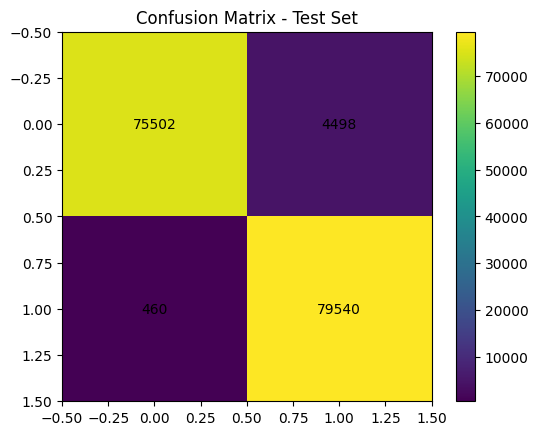

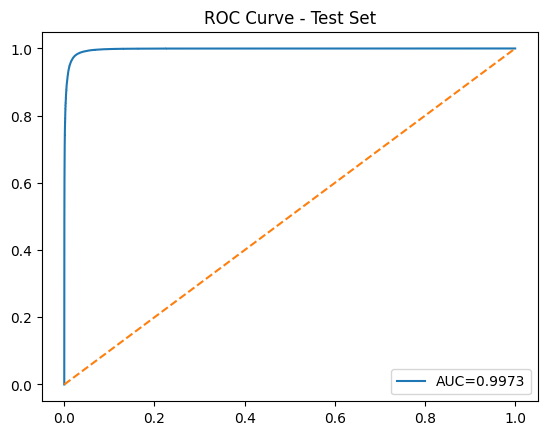

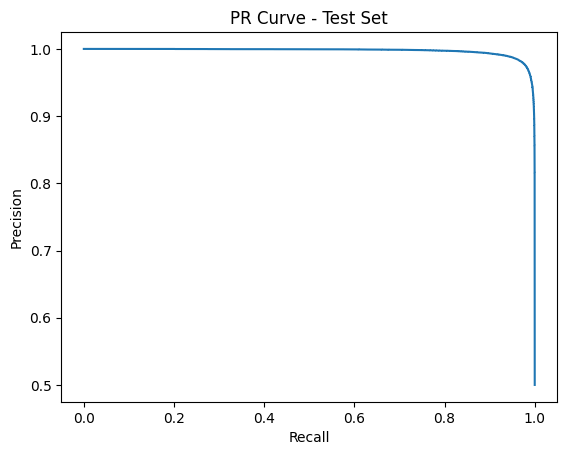


📊 PhiUSIIL Dataset
Accuracy : 0.7867724082359677
Precision: 0.7284223377016238
Recall   : 0.9999777530589544
F1-score : 0.8428675009063293


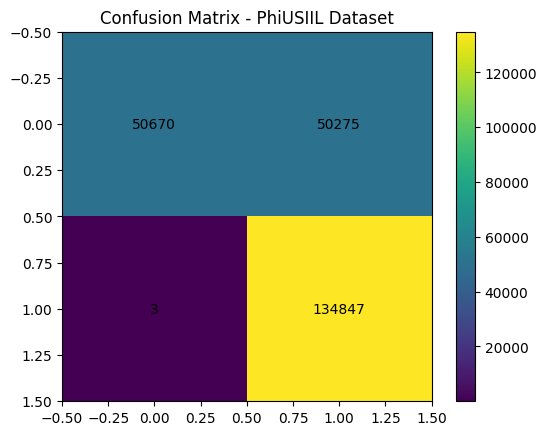

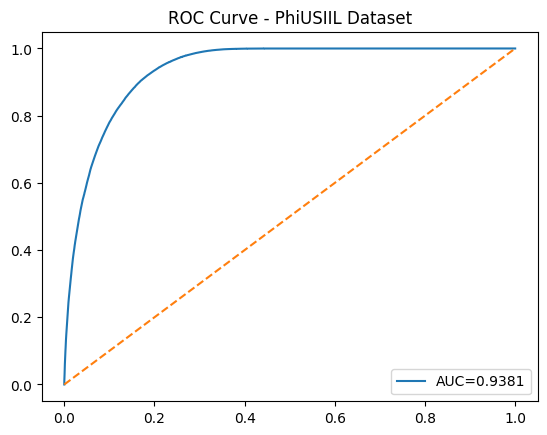

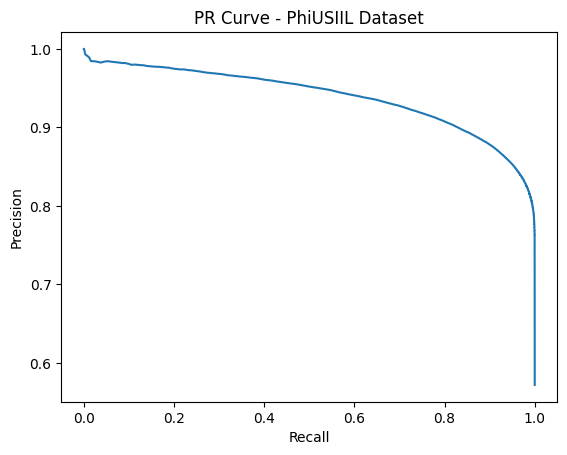

In [ ]:
# ======================================
# ONE-CELL COMPLETE TINY TCN IMPLEMENTATION
# ======================================

# -------- 1. Mount Google Drive --------
from google.colab import drive
drive.mount("/content/drive")

# -------- 2. Imports --------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

# -------- 3. File Paths --------
BASE_PATH = "/content/drive/MyDrive/data"
TRAIN_PATH = os.path.join(BASE_PATH, "train.csv")
TEST_PATH = os.path.join(BASE_PATH, "test.csv")
PHIUSIIL_PATH = os.path.join(BASE_PATH, "phiusiil.csv")

# -------- 4. Safety Check --------
for p in [TRAIN_PATH, TEST_PATH, PHIUSIIL_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")
print("✅ All datasets found")

# -------- 5. Load & Clean Data --------
def load_and_clean(path):
    df = pd.read_csv(path)
    if os.path.basename(path) == "phiusiil.csv":
        df = df[['URL', 'label']].rename(columns={'URL': 'url', 'label': 'labels'})
    else:
        df = df[['url', 'labels']]
    df.dropna(inplace=True)
    df['labels'] = df['labels'].astype(int)
    return df

train_df = load_and_clean(TRAIN_PATH)
test_df  = load_and_clean(TEST_PATH)
phi_df   = load_and_clean(PHIUSIIL_PATH)

print("Train:", train_df.shape, "Test:", test_df.shape, "PhiUSIIL:", phi_df.shape)

# -------- 6. Character Tokenizer --------
MAX_LEN = 128
all_urls = pd.concat([train_df['url'], test_df['url']])
chars = sorted(set("".join(all_urls)))

char2idx = {c: i+1 for i, c in enumerate(chars)}
char2idx["<PAD>"] = 0
vocab_size = len(char2idx)

def encode_url(url):
    seq = [char2idx.get(c, 0) for c in url[:MAX_LEN]]
    return seq + [0]*(MAX_LEN - len(seq))

# -------- 7. Dataset Class --------
class URLDataset(Dataset):
    def __init__(self, urls, labels):
        self.X = [encode_url(u) for u in urls]
        self.y = labels.values

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.float)
        )

# -------- 8. DataLoaders --------
BATCH_SIZE = 128

train_loader = DataLoader(URLDataset(train_df['url'], train_df['labels']),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(URLDataset(test_df['url'], test_df['labels']),
                          batch_size=BATCH_SIZE)
phi_loader   = DataLoader(URLDataset(phi_df['url'], phi_df['labels']),
                          batch_size=BATCH_SIZE)

# -------- 9. Tiny TCN Model --------
class ResidualBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv2(self.relu(self.conv1(x))) + x)

class TinyTCN(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.conv_in = nn.Conv1d(64, 64, 3, padding=1)
        self.block1 = ResidualBlock(64, dilation=1)
        self.block2 = ResidualBlock(64, dilation=2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)      # [B, L, 64]
        x = x.transpose(1, 2)      # [B, 64, L]
        x = self.conv_in(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x).squeeze()

# -------- 10. Training Setup --------
device = torch.device("cpu")
model = TinyTCN(vocab_size).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 5

# -------- 11. Training --------
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss:.4f}")

# -------- 12. Evaluation Function --------
def evaluate(loader, name):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for X, y in loader:
            logits = model(X)
            probs = torch.sigmoid(logits)
            y_true.extend(y.numpy())
            y_prob.extend(probs.numpy())
            y_pred.extend((probs > 0.5).int().numpy())

    print(f"\n📊 {name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f"ROC Curve - {name}")
    plt.show()

    p, r, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(r, p)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.show()

# -------- 13. Run Evaluation --------
evaluate(test_loader, "Test Set")
evaluate(phi_loader, "PhiUSIIL Dataset")
